# LAB - 2 EXTRACTION OF LATENT FEATURE EXTRACTION USING CNN FOR IMAGE DATA SET

## Part A: Grayscale Medical Image CNN

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Input
from tensorflow.keras.preprocessing.image import load_img, img_to_array

from scipy.signal import convolve2d

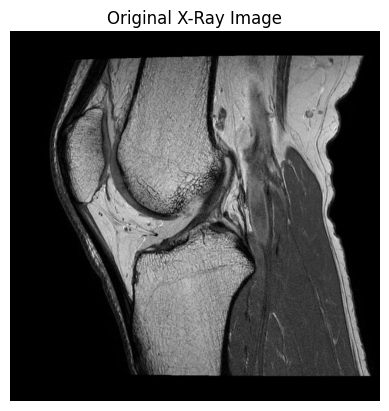

In [2]:
#loading the grayscale image
img = cv2.imread("kneemri.jpg", cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap='gray')
plt.title("Original X-Ray Image")
plt.axis('off')
plt.show()

In [4]:
#processing the image 
img = cv2.resize(img, (128,128))
img = img / 255.0

img_tensor = np.expand_dims(img, axis=-1)
img_tensor = np.expand_dims(img_tensor, axis=0)

print(img_tensor.shape)

(1, 128, 128, 1)


Part B: User-Defined Filters

In [5]:
#edge detection filter

edge_filter = np.array([
    [-1,-1,-1],
    [-1,8,-1],
    [-1,-1,-1]
])

In [6]:
#texture filter

texture_filter = np.array([
    [1,-2,1],
    [-2,4,-2],
    [1,-2,1]
])

In [7]:
#shape filter

shape_filter = np.array([
    [0,1,0],
    [1,-4,1],
    [0,1,0]
])

In [8]:
#applying the user filters

edge_output = convolve2d(img, edge_filter, mode='same')
texture_output = convolve2d(img, texture_filter, mode='same')
shape_output = convolve2d(img, shape_filter, mode='same')

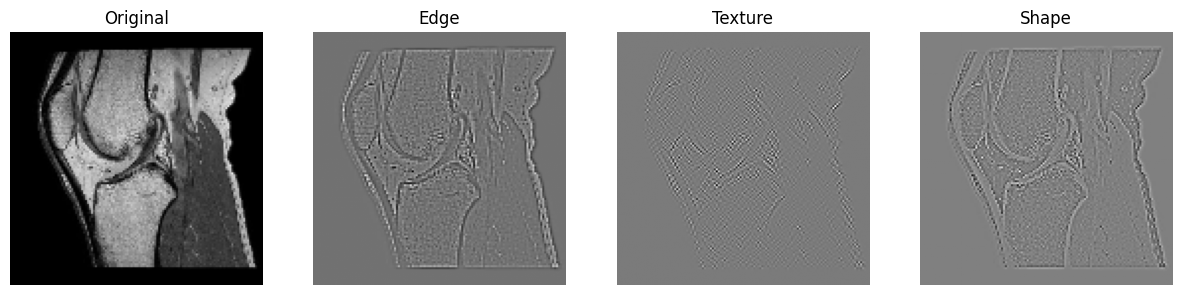

In [10]:
fig,ax = plt.subplots(1,4,figsize=(15,5))

ax[0].imshow(img,cmap='gray')
ax[0].set_title("Original")

ax[1].imshow(edge_output,cmap='gray')
ax[1].set_title("Edge")

ax[2].imshow(texture_output,cmap='gray')
ax[2].set_title("Texture")

ax[3].imshow(shape_output,cmap='gray')
ax[3].set_title("Shape")

for a in ax:
    a.axis('off')

plt.show()

Part C: Built-In CNN

In [11]:
inputs = Input(shape=(128,128,1))

conv1 = Conv2D(8,(3,3),activation='relu',name='conv1')(inputs)
pool1 = MaxPooling2D((2,2))(conv1)

conv2 = Conv2D(16,(3,3),activation='relu',name='conv2')(pool1)
pool2 = MaxPooling2D((2,2))(conv2)

conv3 = Conv2D(32,(3,3),activation='relu',name='conv3')(pool2)
pool3 = MaxPooling2D((2,2))(conv3)

flat = Flatten()(pool3)

latent = Dense(64,name='latent_vector')(flat)

model = Model(inputs, latent)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 126, 126, 8)    │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 61, 61, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 28, 28, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (Dense)           │ (None, 64)             │       401,472 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,360 (1.55 MB)

 Trainable params: 407,360 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
#extract intermediate feature maps

feature_model = Model(
    inputs=model.input,
    outputs=[
        conv1,
        pool1,
        conv2,
        pool2,
        conv3,
        pool3,
        latent
    ]
)

outputs = feature_model.predict(img_tensor)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step


In [20]:
#visulaization function
def visualize_feature_maps(feature_maps, layer_name):

    n_filters = feature_maps.shape[-1]

    plt.figure(figsize=(15,8))

    for i in range(n_filters):

        plt.subplot(4,8,i+1)

        plt.imshow(feature_maps[0,:,:,i], cmap='gray')

        plt.axis('off')

    plt.suptitle(
        f"{layer_name}\nFilters Used = {n_filters}"
    )

    plt.show()

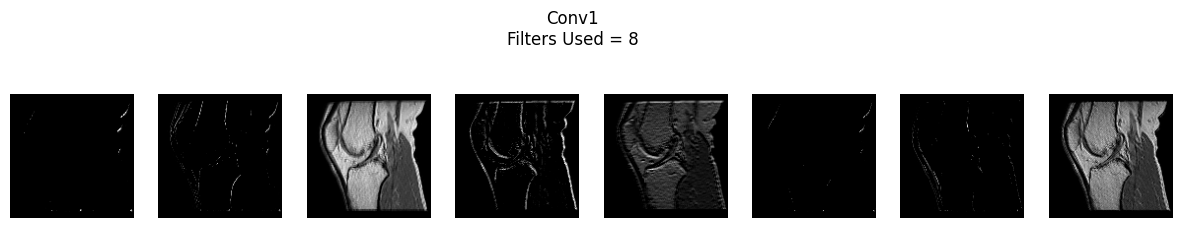

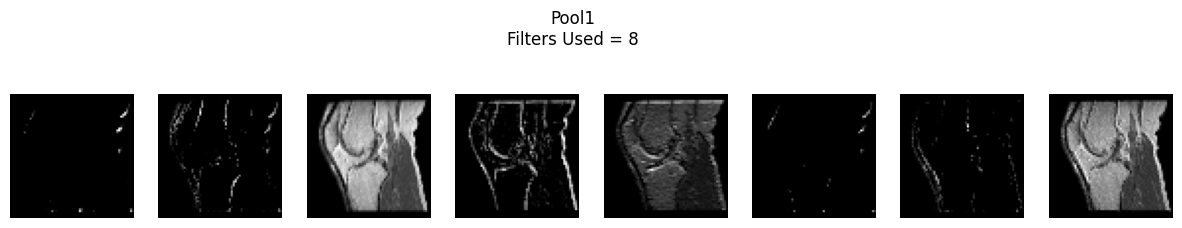

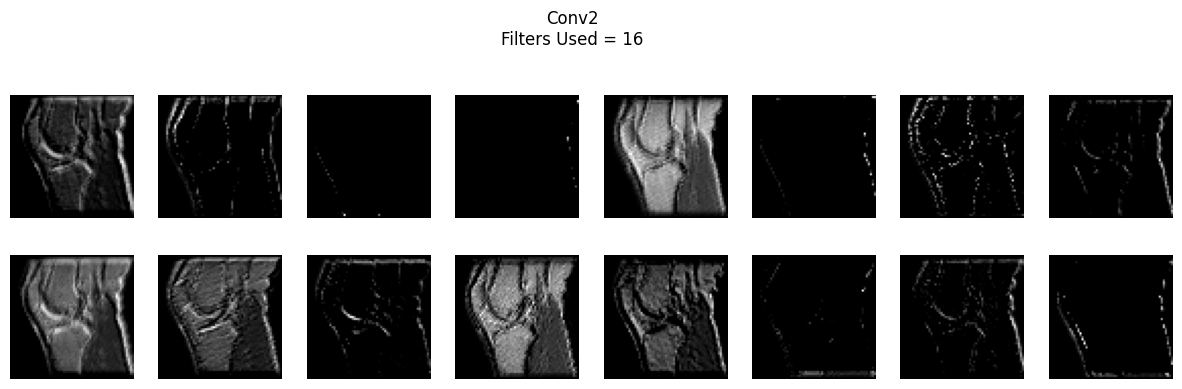

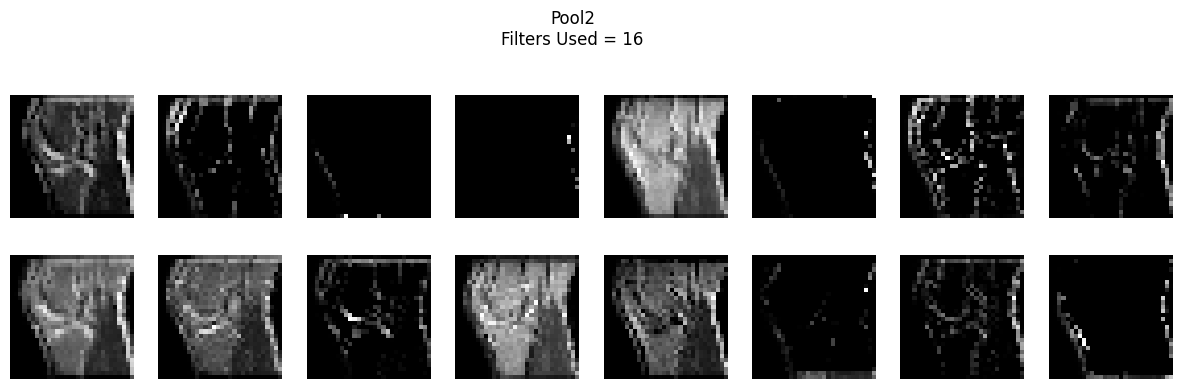

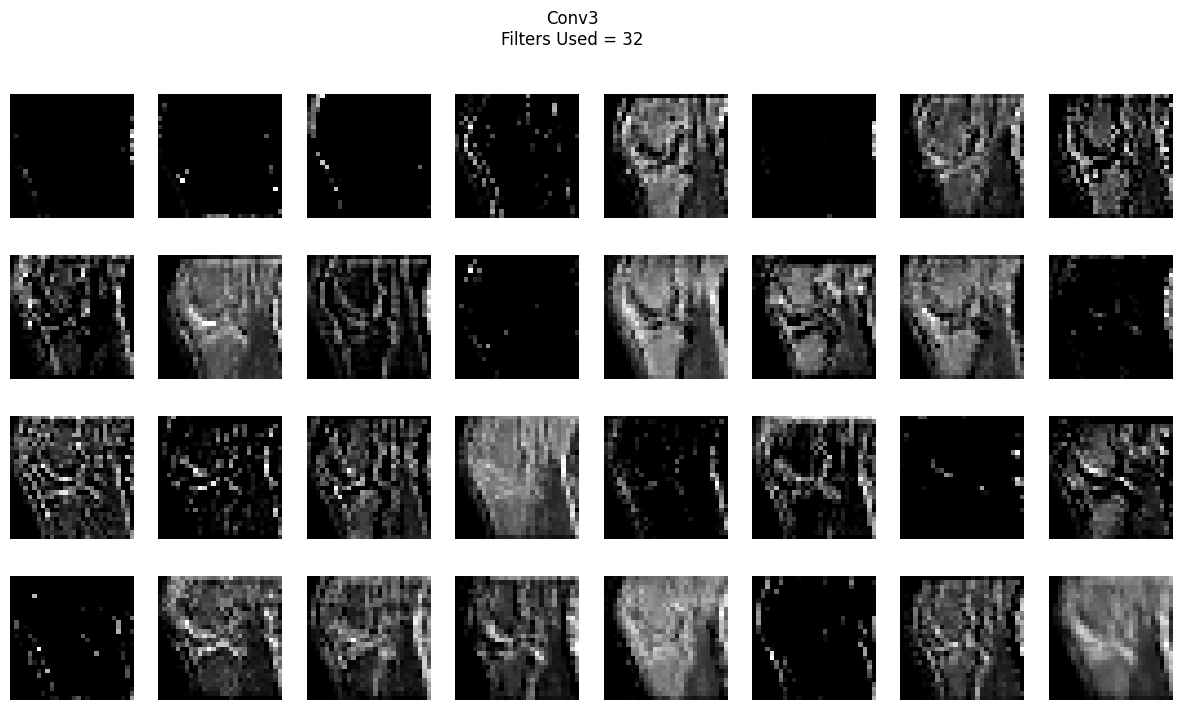

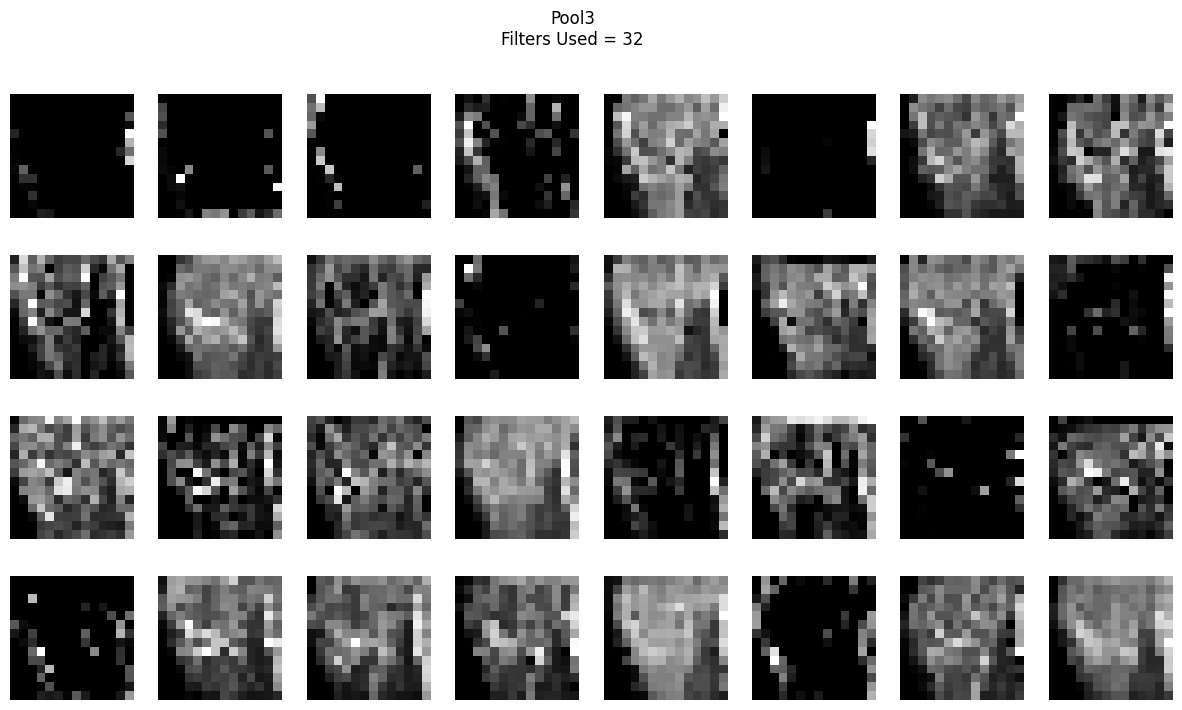

In [21]:
#visualizing every layer
visualize_feature_maps(outputs[0],"Conv1")
visualize_feature_maps(outputs[1],"Pool1")

visualize_feature_maps(outputs[2],"Conv2")
visualize_feature_maps(outputs[3],"Pool2")

visualize_feature_maps(outputs[4],"Conv3")
visualize_feature_maps(outputs[5],"Pool3")

In [22]:
#flattened representation 
flatten_model = Model(inputs=model.input, outputs=flat)

flatten_features = flatten_model.predict(img_tensor)

print(flatten_features.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
(1, 6272)


In [24]:
#latent vector

latent_vector = outputs[-1]
print(latent_vector.shape)

(1, 64)


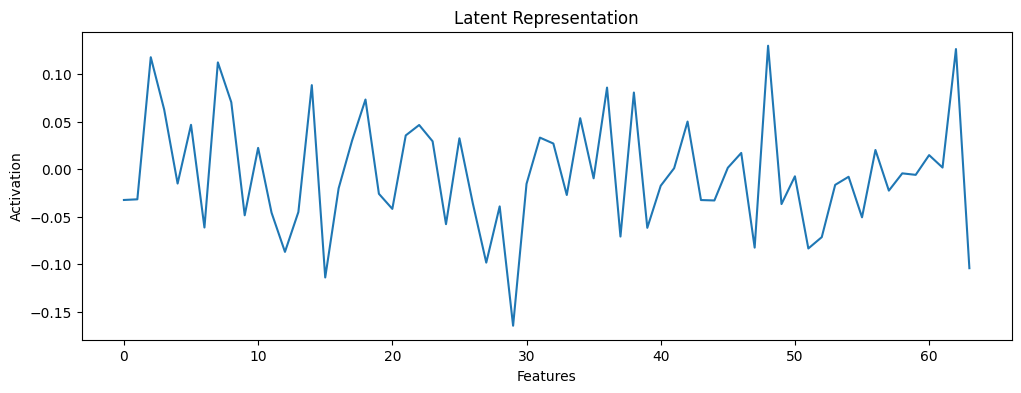

In [25]:
#plot latent vector

plt.figure(figsize=(12,4))
plt.plot(latent_vector[0])
plt.title("Latent Representation")
plt.xlabel("Features")
plt.ylabel("Activation")
plt.show()

Part D: RGB Image CNN

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense
)

from tensorflow.keras.models import Model

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [33]:
#load rgb image

# Change this to your image name
image_path = "butterfly.jpg"

# Read image using OpenCV
image = cv2.imread(image_path)

# Check whether image was loaded
if image is None:
    raise FileNotFoundError(
        "Image not found. Please upload cat.jpg to Colab."
    )

print("Image loaded successfully.")

# OpenCV loads images in BGR format.
# Convert BGR -> RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print("Original image shape:", image.shape)
print("Data type:", image.dtype)
print("Minimum pixel value:", image.min())
print("Maximum pixel value:", image.max())

Image loaded successfully.
Original image shape: (451, 680, 3)
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255


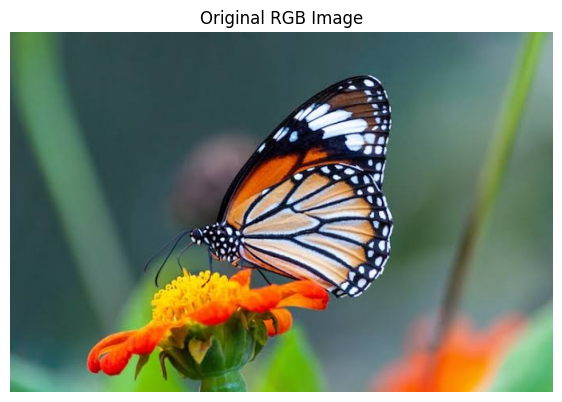

In [34]:
plt.figure(figsize=(7, 7))

plt.imshow(image)

plt.title("Original RGB Image")

plt.axis("off")

plt.show()


In [35]:
image_resized = cv2.resize(
    image,
    (128, 128)
)

print("Resized image shape:", image_resized.shape)

Resized image shape: (128, 128, 3)


In [36]:
#normalizing pixel values

# Convert uint8 -> float32 first
image_normalized = image_resized.astype(np.float32) / 255.0

print("Normalized minimum:", image_normalized.min())
print("Normalized maximum:", image_normalized.max())

Normalized minimum: 0.0
Normalized maximum: 1.0


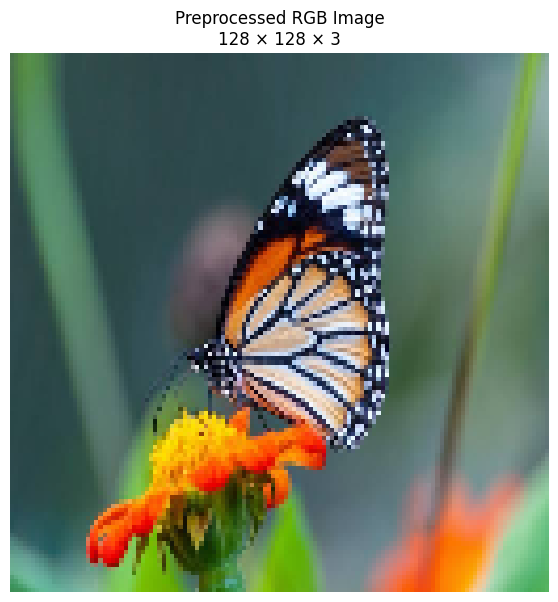

In [37]:
#display prreprocessed image

plt.figure(figsize=(7, 7))

plt.imshow(image_normalized)

plt.title(
    "Preprocessed RGB Image\n128 × 128 × 3"
)

plt.axis("off")

plt.show()

In [38]:
# Convert image into tensor
# Add batch dimension

image_tensor = np.expand_dims(
    image_normalized,
    axis=0
)

print("Tensor shape:", image_tensor.shape)
print("Tensor data type:", image_tensor.dtype)

Tensor shape: (1, 128, 128, 3)
Tensor data type: float32


In [39]:
# USER-DEFINED EDGE FILTER

edge_kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=np.float32)

In [40]:
# USER-DEFINED TEXTURE FILTER
texture_kernel = np.array([
    [ 1, -1,  1],
    [-1,  1, -1],
    [ 1, -1,  1]
], dtype=np.float32)


In [41]:
# USER-DEFINED SHAPE FILTER

shape_kernel = np.array([
    [ 0,  1,  0],
    [ 1, -4,  1],
    [ 0,  1,  0]
], dtype=np.float32)

In [42]:
# APPLY USER-DEFINED FILTER\

def apply_filter_rgb(image, kernel):

    output = np.zeros_like(image)

    for channel in range(3):

        output[:, :, channel] = cv2.filter2D(
            image[:, :, channel],
            -1,
            kernel
        )

    return output

In [43]:
edge_output = apply_filter_rgb(
    image_normalized,
    edge_kernel
)

texture_output = apply_filter_rgb(
    image_normalized,
    texture_kernel
)

shape_output = apply_filter_rgb(
    image_normalized,
    shape_kernel
)

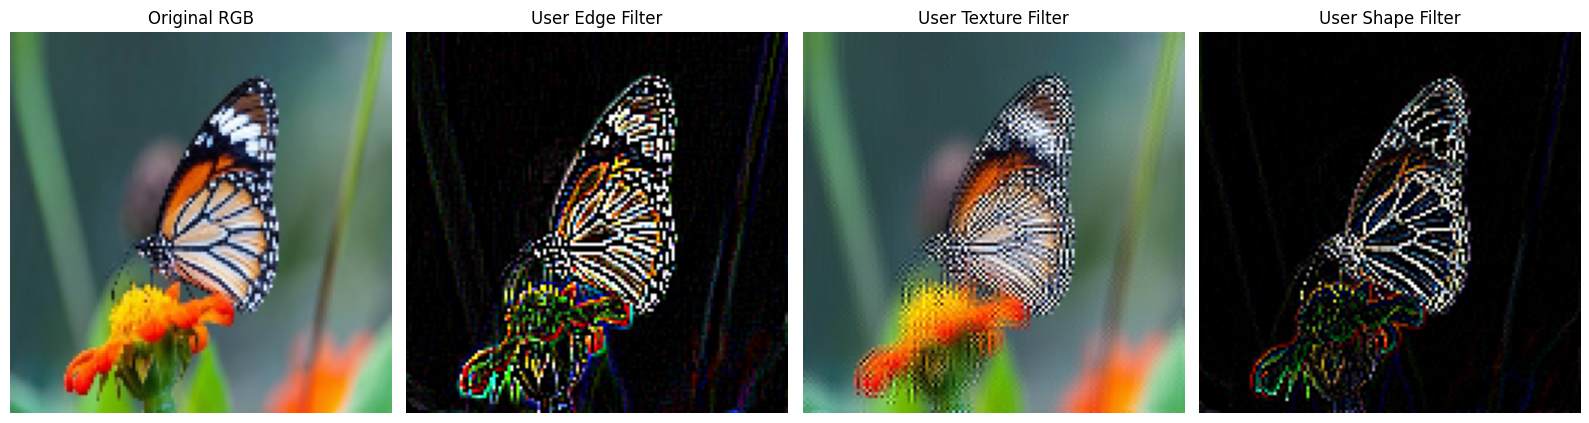

In [44]:
# VISUALIZE USER-DEFINED FILTER OUTPUTS

plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1)

plt.imshow(image_normalized)

plt.title("Original RGB")

plt.axis("off")


plt.subplot(1, 4, 2)

plt.imshow(np.clip(edge_output, 0, 1))

plt.title("User Edge Filter")

plt.axis("off")


plt.subplot(1, 4, 3)

plt.imshow(np.clip(texture_output, 0, 1))

plt.title("User Texture Filter")

plt.axis("off")


plt.subplot(1, 4, 4)

plt.imshow(np.clip(shape_output, 0, 1))

plt.title("User Shape Filter")

plt.axis("off")


plt.tight_layout()

plt.show()

In [45]:
# CNN ARCHITECTURE


inputs = Input(
    shape=(128, 128, 3),
    name="RGB_Input"
)

# CONVOLUTION LAYER 1
conv1 = Conv2D(
    filters=16,
    kernel_size=(3, 3),
    padding="same",
    activation="relu",
    name="Conv1"
)(inputs)


pool1 = MaxPooling2D(
    pool_size=(2, 2),
    name="Pool1"
)(conv1)

# CONVOLUTION LAYER 2
conv2 = Conv2D(
    filters=32,
    kernel_size=(3, 3),
    padding="same",
    activation="relu",
    name="Conv2"
)(pool1)


pool2 = MaxPooling2D(
    pool_size=(2, 2),
    name="Pool2"
)(conv2)


# CONVOLUTION LAYER 3
conv3 = Conv2D(
    filters=64,
    kernel_size=(3, 3),
    padding="same",
    activation="relu",
    name="Conv3"
)(pool2)


pool3 = MaxPooling2D(
    pool_size=(2, 2),
    name="Pool3"
)(conv3)

# FLATTEN
flatten = Flatten(
    name="Flatten"
)(pool3)

# LATENT VECTOR
latent = Dense(
    128,
    activation="relu",
    name="Latent_Vector"
)(flatten)

# CREATE MODEL
cnn_model = Model(
    inputs=inputs,
    outputs=latent
)

# MODEL SUMMARY
cnn_model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ RGB_Input (InputLayer)          │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1 (Conv2D)                  │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool1 (MaxPooling2D)            │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool2 (MaxPooling2D)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3 (Conv2D)                  │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool3 (MaxPooling2D)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Latent_Vector (Dense)           │ (None, 128)            │     2,097,280 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,120,864 (8.09 MB)

 Trainable params: 2,120,864 (8.09 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
#creating feature extraction odel
feature_model = Model(
    inputs=inputs,
    outputs=[
        conv1,
        pool1,
        conv2,
        pool2,
        conv3,
        pool3,
        flatten,
        latent
    ]
)


In [47]:
#extract all features
features = feature_model.predict(
    image_tensor,
    verbose=0
)


conv1_features = features[0]
pool1_features = features[1]

conv2_features = features[2]
pool2_features = features[3]

conv3_features = features[4]
pool3_features = features[5]

flatten_features = features[6]

latent_features = features[7]

#printing shapes
print("======================================")
print("CNN FEATURE MAP SHAPES")
print("======================================")

print("Conv1 :", conv1_features.shape)
print("Pool1 :", pool1_features.shape)

print("Conv2 :", conv2_features.shape)
print("Pool2 :", pool2_features.shape)

print("Conv3 :", conv3_features.shape)
print("Pool3 :", pool3_features.shape)

print("Flatten :", flatten_features.shape)

print("Latent :", latent_features.shape)

CNN FEATURE MAP SHAPES
Conv1 : (1, 128, 128, 16)
Pool1 : (1, 64, 64, 16)
Conv2 : (1, 64, 64, 32)
Pool2 : (1, 32, 32, 32)
Conv3 : (1, 32, 32, 64)
Pool3 : (1, 16, 16, 64)
Flatten : (1, 16384)
Latent : (1, 128)


In [48]:
#visulaisation function

def show_feature_maps(
    feature_maps,
    layer_name,
    number_of_filters
):

    print("\n======================================")
    print(layer_name)
    print("Number of filters:", number_of_filters)
    print("Feature map shape:", feature_maps.shape)
    print("======================================")

    rows = int(np.ceil(number_of_filters / 8))

    plt.figure(
        figsize=(18, rows * 2.5)
    )

    for i in range(number_of_filters):

        plt.subplot(
            rows,
            8,
            i + 1
        )

        feature_map = feature_maps[0, :, :, i]

        plt.imshow(
            feature_map,
            cmap="gray"
        )

        plt.title(
            f"Filter {i + 1}"
        )

        plt.axis("off")

    plt.suptitle(
        f"{layer_name} | {number_of_filters} Filters",
        fontsize=18
    )

    plt.tight_layout()

    plt.show()


CONVOLUTION LAYER 1
Number of filters: 16
Feature map shape: (1, 128, 128, 16)


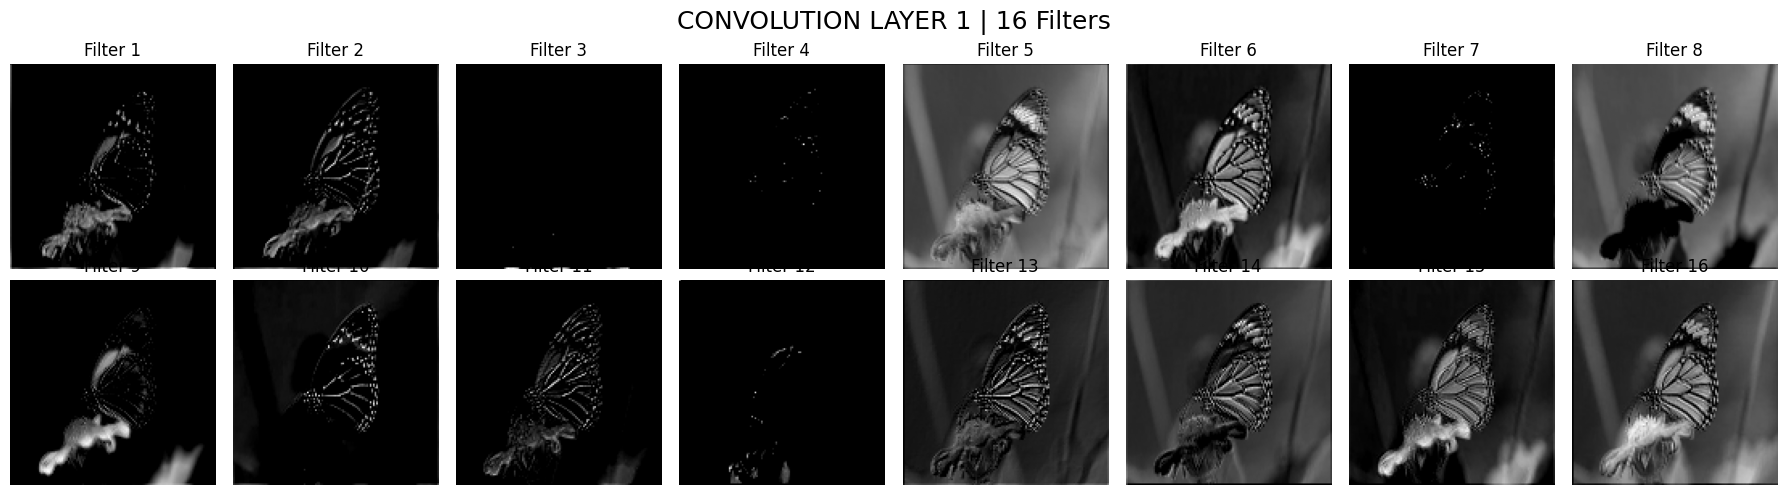


POOLING LAYER 1
Number of filters: 16
Feature map shape: (1, 64, 64, 16)


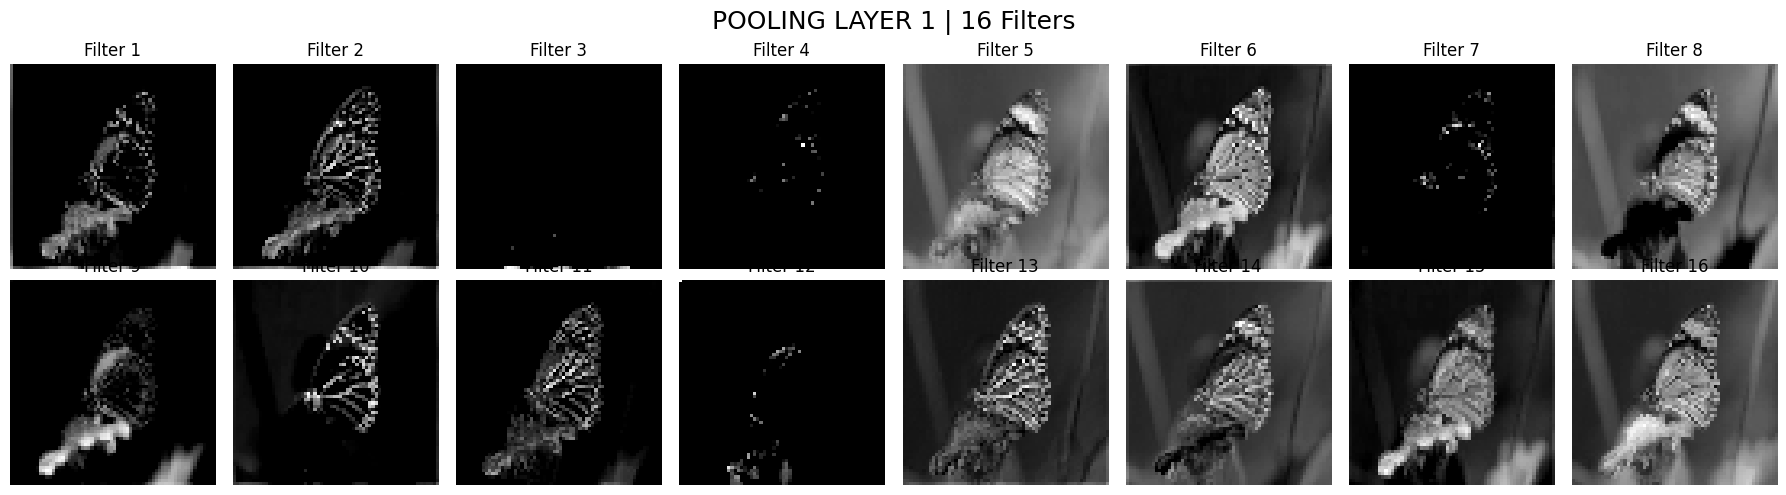

In [50]:
show_feature_maps(
    conv1_features,
    "CONVOLUTION LAYER 1",
    16
)

show_feature_maps(
    pool1_features,
    "POOLING LAYER 1",
    16
)


CONVOLUTION LAYER 2
Number of filters: 32
Feature map shape: (1, 64, 64, 32)


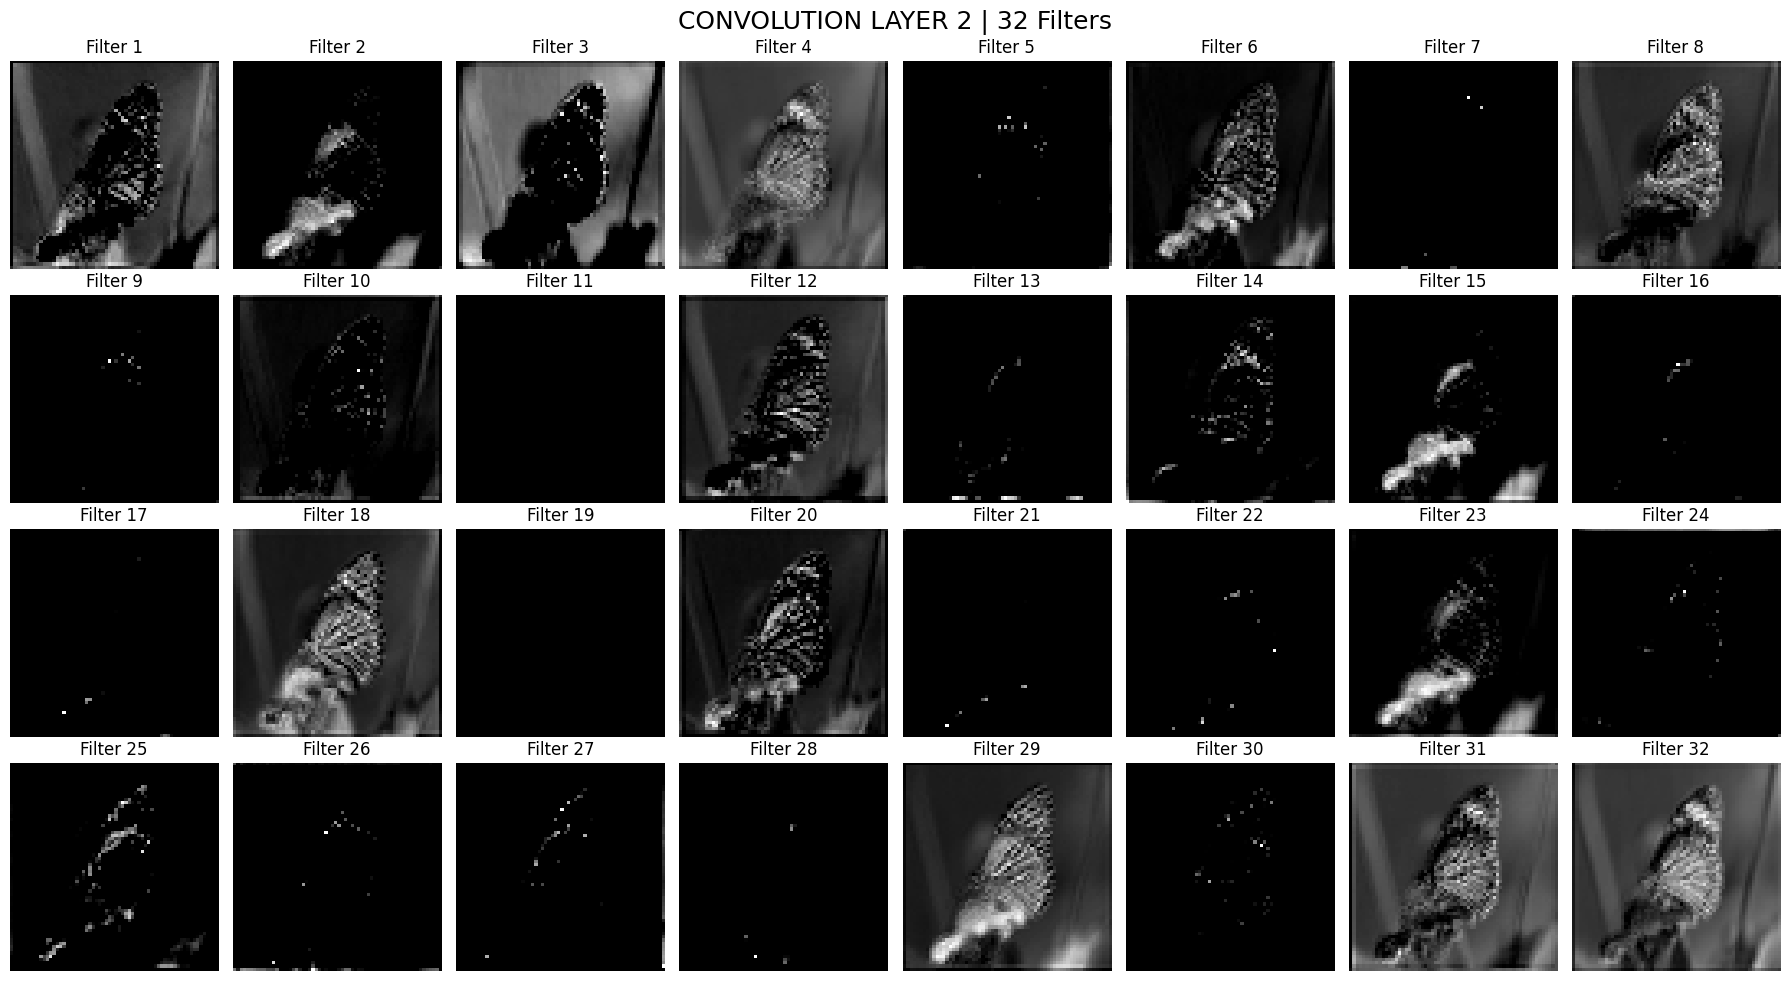


POOLING LAYER 2
Number of filters: 32
Feature map shape: (1, 32, 32, 32)


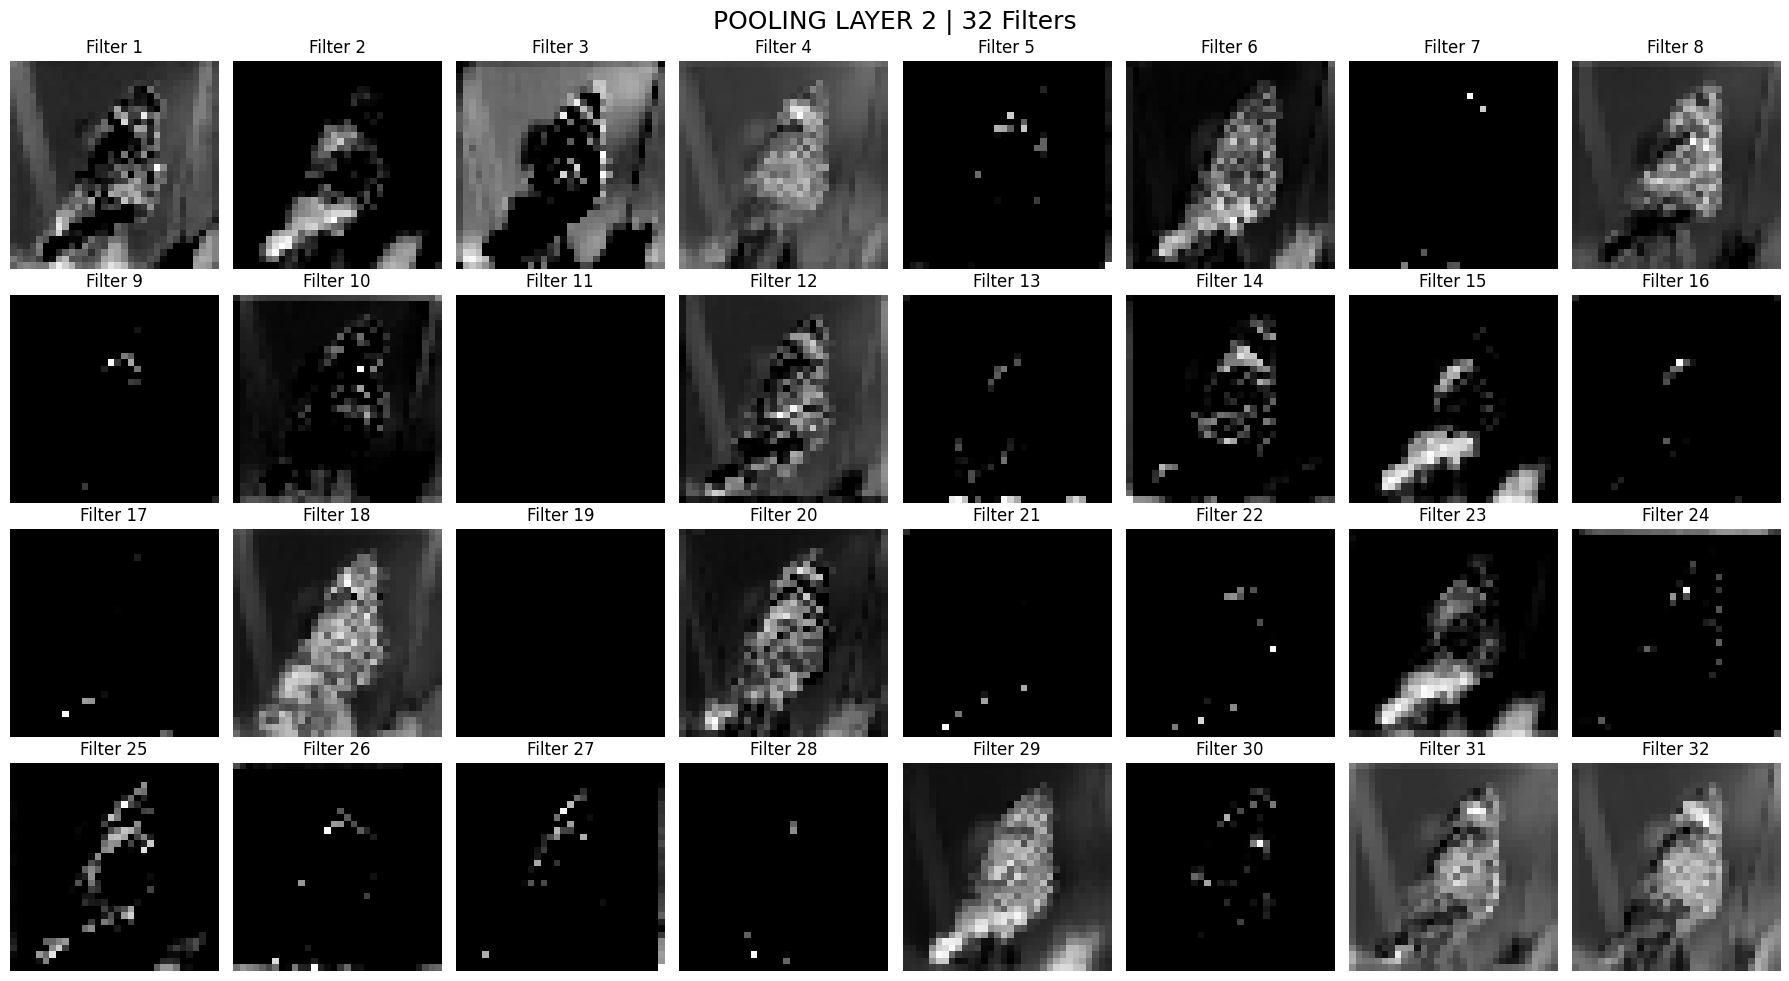

In [51]:
show_feature_maps(
    conv2_features,
    "CONVOLUTION LAYER 2",
    32
)

show_feature_maps(
    pool2_features,
    "POOLING LAYER 2",
    32
)


CONVOLUTION LAYER 3
Number of filters: 64
Feature map shape: (1, 32, 32, 64)


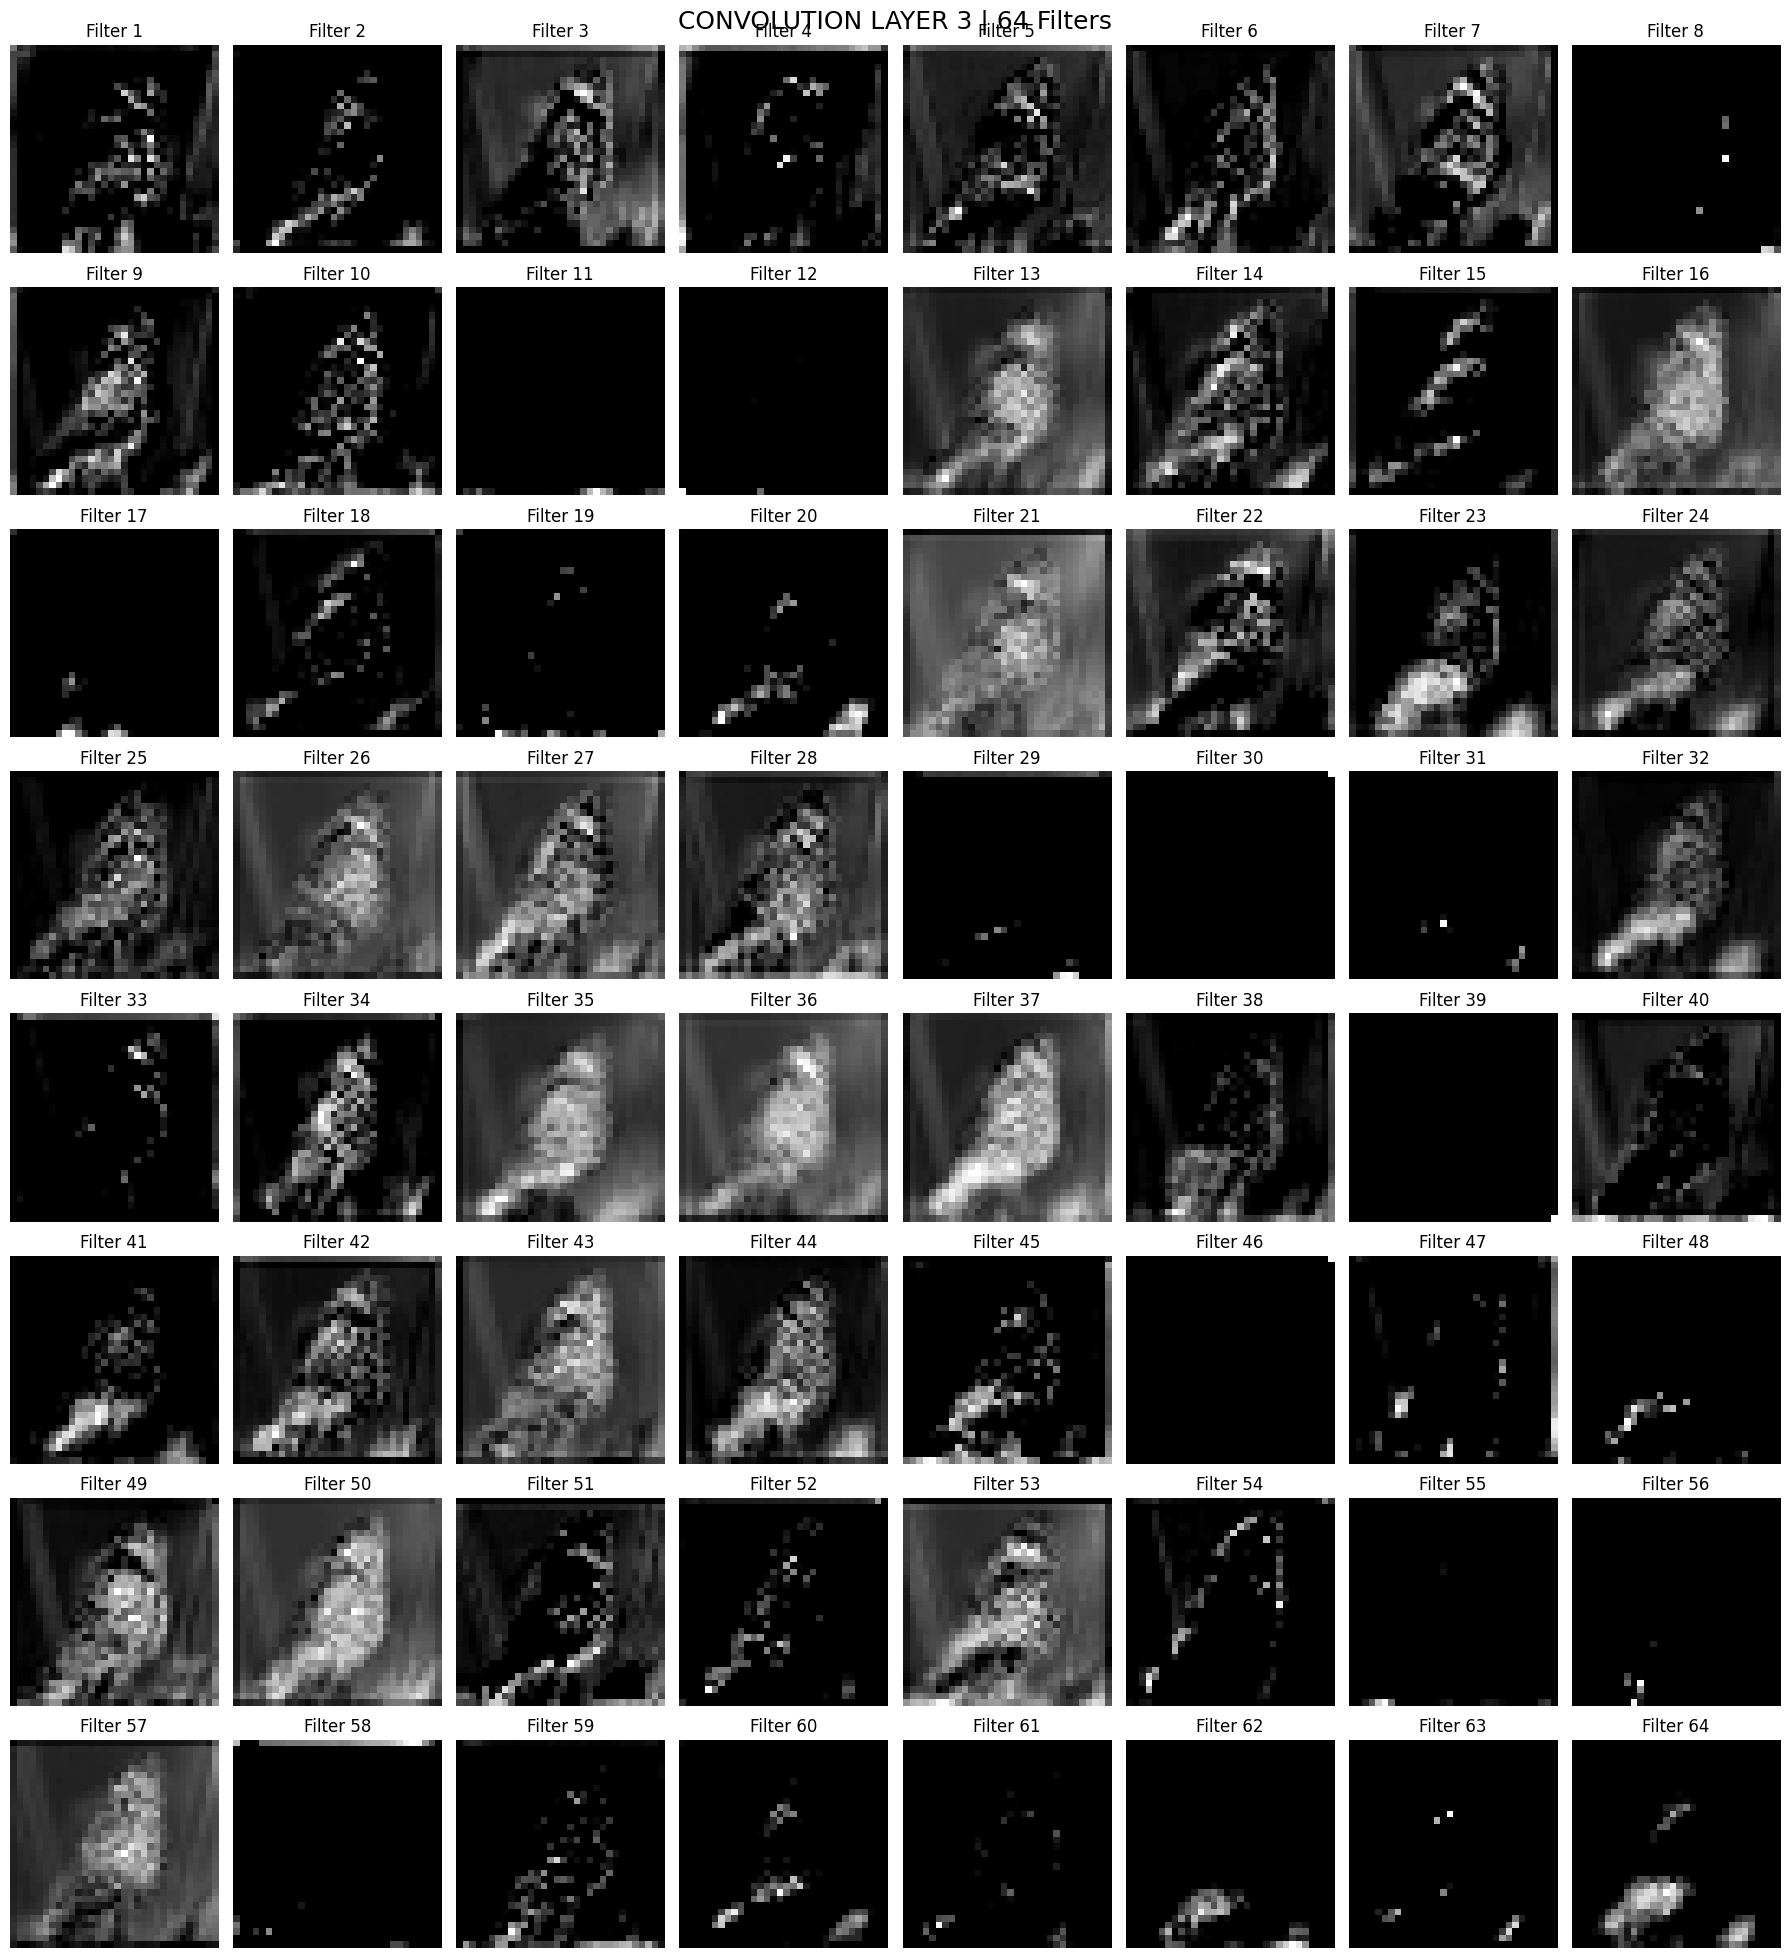


POOLING LAYER 3
Number of filters: 64
Feature map shape: (1, 16, 16, 64)


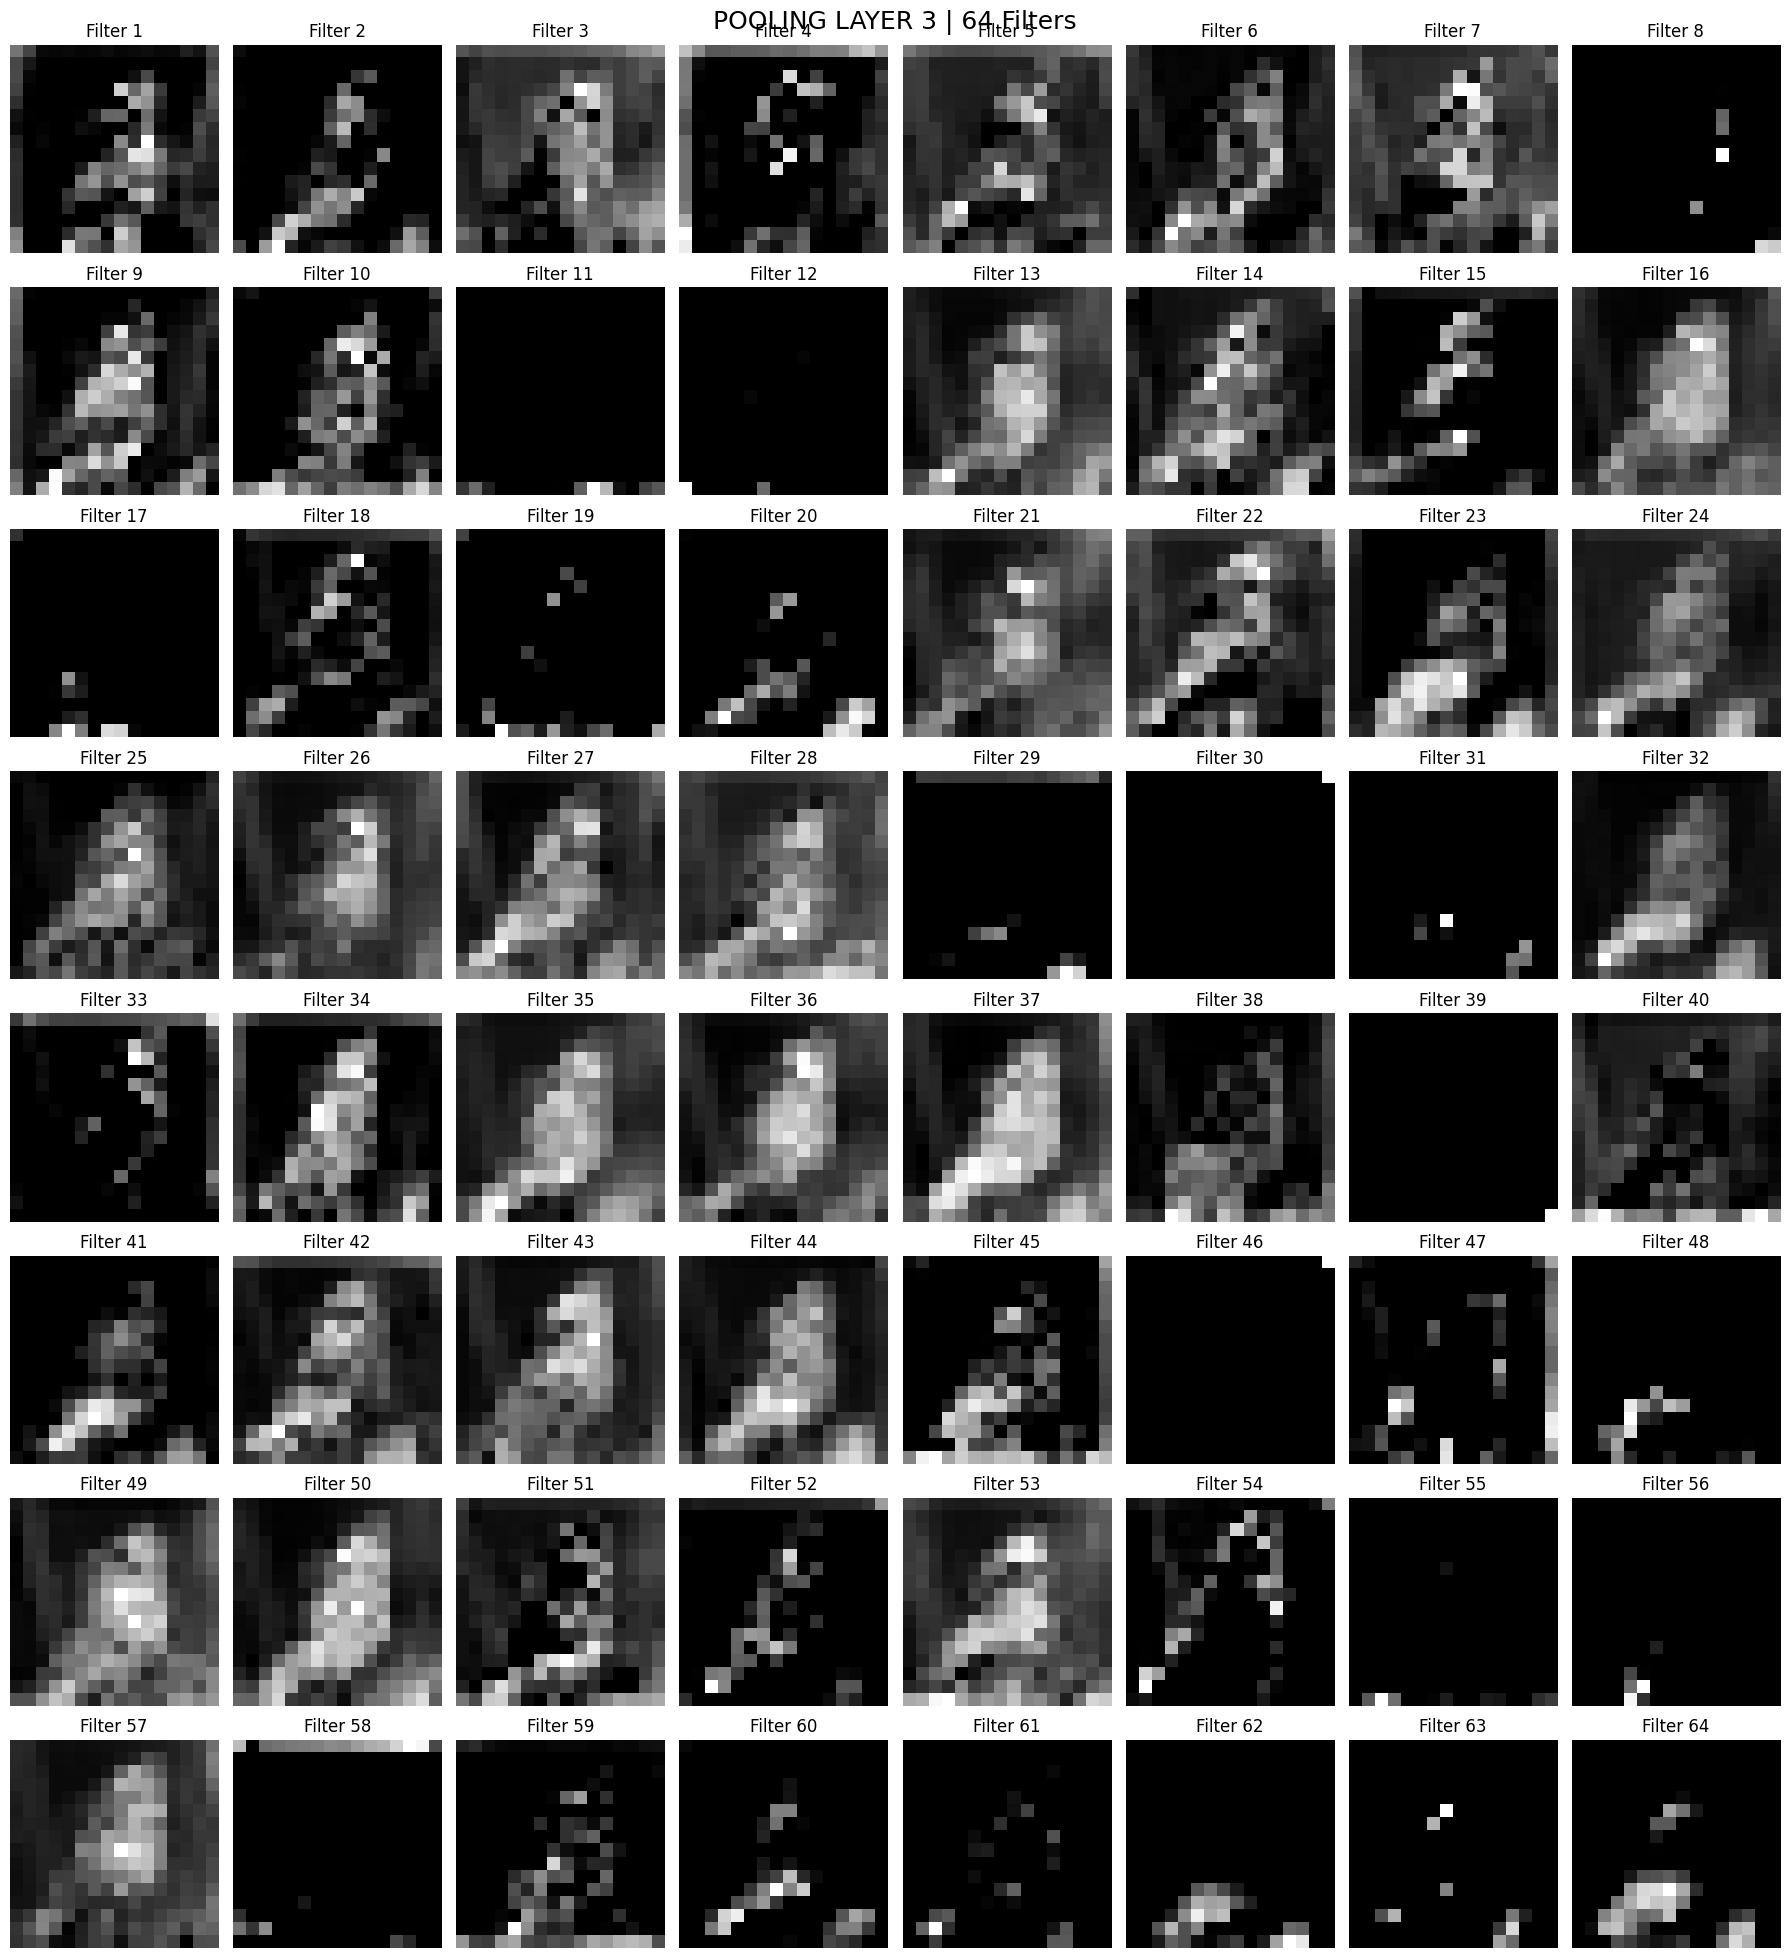

In [54]:
show_feature_maps(
    conv3_features,
    "CONVOLUTION LAYER 3",
    64
)

show_feature_maps(
    pool3_features,
    "POOLING LAYER 3",
    64
)

In [55]:
#flatten

print("======================================")
print("FLATTENED FEATURE REPRESENTATION")
print("======================================")

print(
    "Shape:",
    flatten_features.shape
)

print(
    "\nFirst 20 features:"
)

print(
    flatten_features[0][:20]
)

FLATTENED FEATURE REPRESENTATION
Shape: (1, 16384)

First 20 features:
[0.03923954 0.00466145 0.0455127  0.03962515 0.0563164  0.02744478
 0.04047748 0.         0.06086525 0.00297474 0.         0.
 0.09122775 0.02203891 0.03991353 0.06812187 0.01350869 0.0024223
 0.01179183 0.00098311]


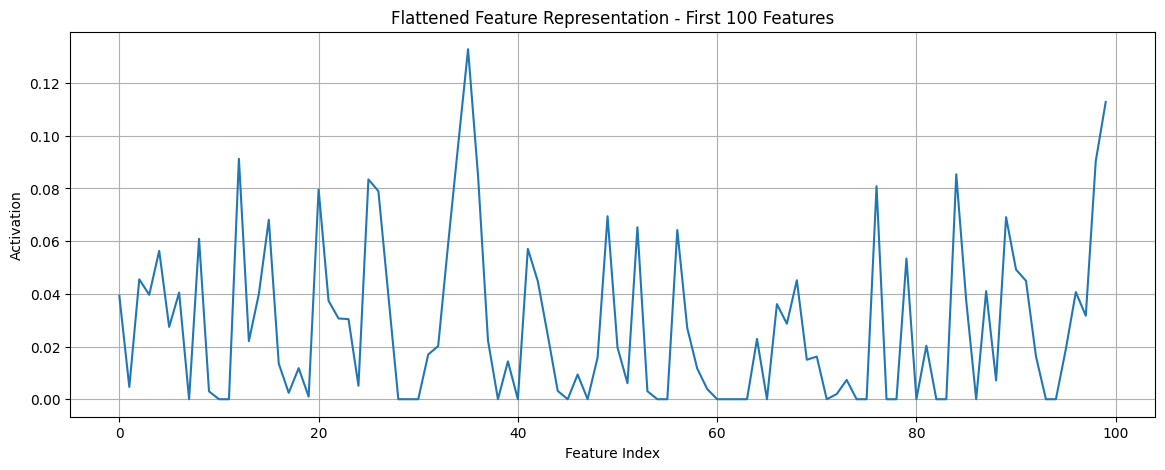

In [56]:
plt.figure(figsize=(14, 5))

plt.plot(
    flatten_features[0][:100]
)

plt.title(
    "Flattened Feature Representation - First 100 Features"
)

plt.xlabel("Feature Index")

plt.ylabel("Activation")

plt.grid()

plt.show()

In [57]:
#latent vector

# ============================================================
# LATENT VECTOR
# ============================================================

print("======================================")
print("FINAL LATENT VECTOR")
print("======================================")

print(
    "Latent vector shape:",
    latent_features.shape
)

print("\n128 Latent Features:")

print(
    latent_features[0]
)

FINAL LATENT VECTOR
Latent vector shape: (1, 128)

128 Latent Features:
[0.         0.0829697  0.         0.         0.         0.
 0.         0.06078375 0.         0.0210869  0.10891275 0.
 0.         0.         0.05215728 0.07001333 0.03446133 0.1157422
 0.09624734 0.01837761 0.04666737 0.06643459 0.11375797 0.
 0.         0.         0.         0.         0.13770802 0.
 0.06987877 0.         0.         0.         0.06079637 0.04231409
 0.         0.06175948 0.08000631 0.         0.         0.
 0.06363321 0.         0.05217432 0.03314596 0.1051118  0.
 0.         0.10227601 0.10623977 0.0448418  0.07881883 0.
 0.         0.         0.         0.02334188 0.04724739 0.
 0.         0.         0.         0.         0.01849147 0.
 0.         0.         0.         0.         0.00314158 0.07317032
 0.04189934 0.         0.14314568 0.05113965 0.         0.02929927
 0.09987509 0.18825108 0.03046044 0.         0.         0.09357322
 0.         0.         0.04250366 0.10773613 0.         0.03091

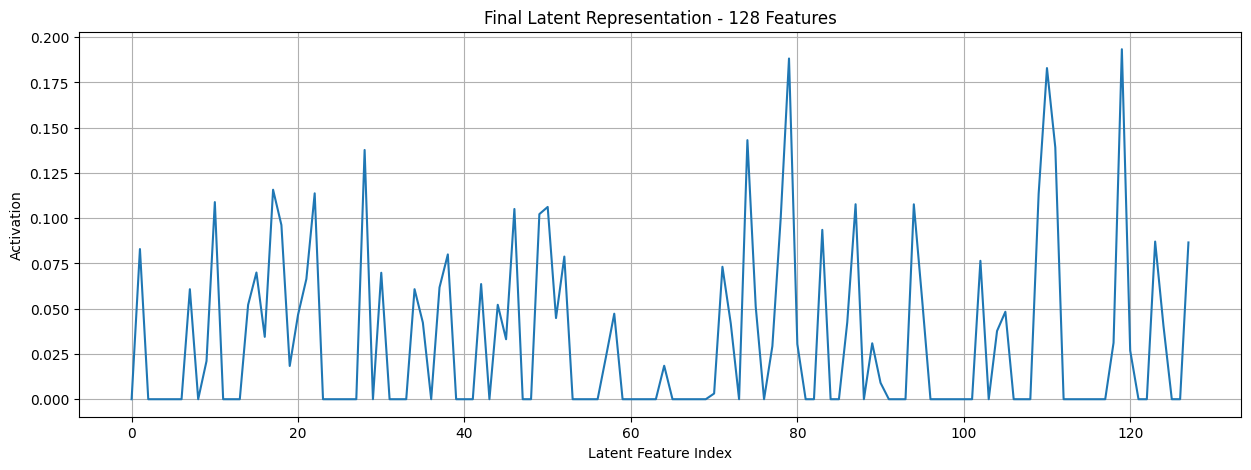

In [58]:
plt.figure(figsize=(15, 5))

plt.plot(
    latent_features[0]
)

plt.title(
    "Final Latent Representation - 128 Features"
)

plt.xlabel(
    "Latent Feature Index"
)

plt.ylabel(
    "Activation"
)

plt.grid()

plt.show()

In [59]:
#complexity analysis

def convolution_complexity(
    height,
    width,
    kernel_size,
    input_channels,
    filters
):

    operations = (
        height
        * width
        * kernel_size
        * kernel_size
        * input_channels
        * filters
    )

    return operations


conv1_operations = convolution_complexity(
    128, 128, 3, 3, 16
)

conv2_operations = convolution_complexity(
    64, 64, 3, 16, 32
)

conv3_operations = convolution_complexity(
    32, 32, 3, 32, 64
)


print("======================================")
print("CNN COMPUTATIONAL COMPLEXITY")
print("======================================")

print(
    "Conv1:",
    conv1_operations,
    "operations"
)

print(
    "Conv2:",
    conv2_operations,
    "operations"
)

print(
    "Conv3:",
    conv3_operations,
    "operations"
)

total_operations = (
    conv1_operations
    + conv2_operations
    + conv3_operations
)

print(
    "\nTotal:",
    total_operations,
    "operations"
)

CNN COMPUTATIONAL COMPLEXITY
Conv1: 7077888 operations
Conv2: 18874368 operations
Conv3: 18874368 operations

Total: 44826624 operations


In [60]:
#parameter complexity

print("======================================")
print("PARAMETER COMPLEXITY")
print("======================================")

for layer in cnn_model.layers:

    print(
        layer.name,
        "->",
        layer.count_params(),
        "parameters"
    )

print(
    "\nTotal parameters:",
    cnn_model.count_params()
)

PARAMETER COMPLEXITY
RGB_Input -> 0 parameters
Conv1 -> 448 parameters
Pool1 -> 0 parameters
Conv2 -> 4640 parameters
Pool2 -> 0 parameters
Conv3 -> 18496 parameters
Pool3 -> 0 parameters
Flatten -> 0 parameters
Latent_Vector -> 2097280 parameters

Total parameters: 2120864
